<a href="https://colab.research.google.com/github/juanrmz85/sprint7-final-project_telecom-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [ ]:
display(plans.head()) # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
display(users.head()) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
display(usage.head()) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print()
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print()
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Despues de hacer la consulta para revisar aquellos valores nulos que puedan regresentar un problema para el analisis de los datos, tenemos las siguientes observaciones:

- En la base de datos de los clientes encontramos que tenemos datos faltantes en la columna de ciudad, probablemente relacionado con una falta de captura en un porcentaje del 11%. En el caso de los datos de la columna churn_date, tenemos un faltante de datos del 88% de los datos.

¿Qué hacer?

Para el caso de los datos faltantes en la columna ciudad, lo ignoramos ya que no es un dato relevante para el análisis que realizaremos. En el caso de la columna churn_date, no es propiamente un dato faltantes, en este caso los valores capturados estan relacionados con la fecha de cancelación del servicio por parte del cliente, por lo que aquellos que tienen dato faltante es por que tienen una linea activa, por lo que de igual manera este dato se ignora.

- En la base de datos de usage, tenemos valores faltantes principalmente en las columas de duration y length, en 55% y 44% de los casos respectivamente.

¿Qué hacer?

Haciendo un analisis de los datos podemos definir que los valores faltantes de cada columna, estan relacionados con el tipo de accion definida en la columna type. Para el caso de aquellos servicios de llamada (call) la columna con dato seria la de duration, que es el tiempo de duracion de la llamada, y para el caso de los mensajes (text) el caso de la columna alimentada es la de length, que es la cantidad de caracteres enviamos en el mensaje. Por lo que hariamos un analisis para asegurar que se cuente con el dato en todas las filas, segun sea requerido, de existir datos faltantes, imputariamos con el promedio.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
columnas_numericas_users = ['user_id', 'age']
print(users[columnas_numericas_users].describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` se trata de un número consecutivo asignado al usuario por el sistema, para identificar su registro.
- La columna `age` contiene valores inválidos (negativos o ceros), generados por una falta o error de captura.

In [ ]:
# explorar columnas numéricas de usage
columnas_numericas_usage = ['id', 'user_id', 'duration', 'length']
print(usage[columnas_numericas_usage].describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`son numeros de registro de usuario y no tienen valores faltantes o invalidos.
- Las columnas duration y lenght, corresponden a registro de actividad de la linea, es necesario evaluarlas para imputar valores faltantes.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())
print()
print('Categorias unicas en columna "city":',users['city'].unique())
print('Categorias unicas en columna "plan":',users['plan'].unique())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595

Categorias unicas en columna "city": ['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Categorias unicas en columna "plan": ['Basico' 'Premium']


- La columna `city` cuenta con valores inválidos, los cuales no afectan el desarrollo de este análisis.
- La columna `plan` describe los tipos de planes contratados, y consta de 2 categorias sin valores inválidos.

In [ ]:
# explorar columna categórica de usage
print(usage['type'].describe())
print()
print('Categorias unicas en columna "type":',usage['type'].unique())

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

Categorias unicas en columna "type": ['call' 'text']


- La columna `type` corresponde a una categoría de dos valores y no cuenta con valores invalidos.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

En el caso de las columnas numericas, encontramos valores invalidos o sentinels (NaN, -999), en las columnas age, duration y length.

- En el caso de la columna age, reemplazariamos los valores -999 y 0, por el valor promedio de la edad.
- Para las columnas duration y length, hariamos un analisis para definir si alguno de los valores invalidos es faltante o no corresponde a la categoría.

Y en relación con las columnas categoricas, encotramos que la columna city tiene valore no validos ("?", "NaN")

- Esta caso solo representa un 12% del total de los valores, y consideramos que no afecta de manera significativa a los análisis que estaremos realizando. Por lo que seran considerados como valores ausentes o NaN.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date`, podemos ver que tenemos registros del año 2026 que no corresponden, al tratarse de una base de datos de años posteriores al 2024.

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.unique())
print()
print(usage['date'].value_counts(dropna=False))

[2024.   nan]

NaT                              50
2024-06-21 22:28:11.862296556     1
2024-06-06 11:09:26.204155102     1
2024-04-14 16:05:21.848046200     1
2024-04-01 14:39:43.079576989     1
                                 ..
2024-02-24 18:57:42.026550663     1
2024-04-13 22:49:17.653941348     1
2024-03-06 03:52:44.749118728     1
2024-03-21 23:20:13.140328508     1
2024-04-08 01:44:47.917197929     1
Name: date, Length: 39951, dtype: int64


En `date`, tenemos valores NaN que seguramente se deben a un error de captura.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

De acuerdo al analisis realizado, tenemos casos de años imposibles ya que la columna "reg_date" de la base de datos "usage", registra hasta el año 2024, y encontramos registros del año 2026. Estos valores seran ignorados ya que no afectan nuestros calculos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
na_antes = users['city'].isna().sum()
users['city'] = users['city'].replace('?', pd.NA)
na_despues = users['city'].isna().sum()

# Verificar cambios
print(users['city'].unique())
print("Na_antes:", na_antes)
print("Na_despues:", na_despues)

['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Na_antes: 469
Na_despues: 565


In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.unique()

array([2022.,   nan, 2023., 2024.])

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['mar_duration'] = np.where(
    (usage['type'] == "call") & (usage['duration'].notna()), "Valid",
        np.where((usage['type'] == "text") & (usage['duration'].isna()), "MAR", "Error"))

print(usage['mar_duration'].value_counts())
print()
usage[usage['mar_duration'] == 'Error']

MAR      22076
Valid    17908
Error       16
Name: mar_duration, dtype: int64



,id,user_id,type,date,duration,length,mar_duration
1414,1415,10399,text,2024-01-07 09:33:51.260781519,120.0,65.0,Error
1824,1825,12936,text,2024-01-09 06:05:28.868221705,120.0,40.0,Error
1932,1933,10189,text,2024-01-09 17:49:13.603840096,120.0,69.0,Error
2972,2973,10085,text,2024-01-14 10:46:02.169054226,120.0,68.0,Error
11456,11457,13325,text,2024-02-21 20:09:09.733743343,120.0,23.0,Error
16702,16703,10484,text,2024-03-16 13:52:57.169429235,120.0,48.0,Error
22814,22815,12711,text,2024-04-13 05:39:44.429610740,120.0,70.0,Error
23052,23053,13850,text,2024-04-14 07:30:35.235880896,120.0,24.0,Error
23451,23452,13265,text,2024-04-16 02:50:32.175804394,120.0,53.0,Error
26561,26562,13920,text,2024-04-30 04:35:48.173704342,120.0,89.0,Error


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['mar_length'] = np.where(
    (usage['type'] == "text") & (usage['length'].notna()), "Valid",
        np.where((usage['type'] == "call") & (usage['length'].isna()), "MAR", "Error"))

print(usage['mar_length'].value_counts())
print()
usage[usage['mar_length'] == 'Error']

Valid    22092
MAR      17896
Error       12
Name: mar_length, dtype: int64



,id,user_id,type,date,duration,length,mar_duration,mar_length
2070,2071,13139,call,2024-01-10 08:48:27.432685817,1.68,1490.0,Valid,Error
5272,5273,11750,call,2024-01-24 20:33:12.649816245,3.78,1490.0,Valid,Error
10614,10615,13855,call,2024-02-18 00:42:33.183829595,0.53,1490.0,Valid,Error
12692,12693,12263,call,2024-02-27 10:23:08.374709367,1.80,1490.0,Valid,Error
16910,16911,12099,call,2024-03-17 12:28:18.882472061,3.29,1490.0,Valid,Error
20727,20728,10599,call,2024-04-03 19:00:30.510762768,0.40,1490.0,Valid,Error
20778,20779,11401,call,2024-04-04 00:32:49.969249231,1.01,1490.0,Valid,Error
25444,25445,10781,call,2024-04-25 03:17:14.935873396,3.57,1490.0,Valid,Error
26057,26058,11018,call,2024-04-27 21:51:39.407485186,0.63,1490.0,Valid,Error
26506,26507,12400,call,2024-04-29 22:37:24.836120902,1.12,1490.0,Valid,Error


#### Diagnostico de nulos en `duration` y `length`

Despues se realizar el análisis de las columnas "duration" y "length" en relación con la columna "type", podemos definir que existe una relacion directa. Para el caso de aquellos valores de tipo "call" el valor capturado es en la columna "duration" que representa el tiempo de duración de la llamada, y para el caso de aquellos valores de tipo "text" la columna alimentada es la de "length", que es la cantidad de caracteres del mensaje de texto.

Como resultado del mismo análisis, pudimos encontrar valores nulos de "call" (12 errores) y "text" (16 errores), que cuentan con captura en ambas columnas. Para estos valores es necesario eliminar el valor nulo para que no afecten nuestros calculos posteriores.

In [ ]:
# Convertimos los errores en NaN para duration
usage.loc[(usage['mar_duration'] == "Error") & (usage['type'] == "text"), 'duration'] = pd.NA

usage[usage['mar_duration'] == 'Error']

,id,user_id,type,date,duration,length,mar_duration,mar_length
1414,1415,10399,text,2024-01-07 09:33:51.260781519,<NA>,65.0,Error,Valid
1824,1825,12936,text,2024-01-09 06:05:28.868221705,<NA>,40.0,Error,Valid
1932,1933,10189,text,2024-01-09 17:49:13.603840096,<NA>,69.0,Error,Valid
2972,2973,10085,text,2024-01-14 10:46:02.169054226,<NA>,68.0,Error,Valid
11456,11457,13325,text,2024-02-21 20:09:09.733743343,<NA>,23.0,Error,Valid
16702,16703,10484,text,2024-03-16 13:52:57.169429235,<NA>,48.0,Error,Valid
22814,22815,12711,text,2024-04-13 05:39:44.429610740,<NA>,70.0,Error,Valid
23052,23053,13850,text,2024-04-14 07:30:35.235880896,<NA>,24.0,Error,Valid
23451,23452,13265,text,2024-04-16 02:50:32.175804394,<NA>,53.0,Error,Valid
26561,26562,13920,text,2024-04-30 04:35:48.173704342,<NA>,89.0,Error,Valid


In [ ]:
# Convertimos los errores en NaN para length
usage.loc[(usage['mar_length'] == "Error") & (usage['type'] == "call"), 'length'] = pd.NA

usage[usage['mar_length'] == 'Error']

,id,user_id,type,date,duration,length,mar_duration,mar_length
2070,2071,13139,call,2024-01-10 08:48:27.432685817,1.68,<NA>,Valid,Error
5272,5273,11750,call,2024-01-24 20:33:12.649816245,3.78,<NA>,Valid,Error
10614,10615,13855,call,2024-02-18 00:42:33.183829595,0.53,<NA>,Valid,Error
12692,12693,12263,call,2024-02-27 10:23:08.374709367,1.8,<NA>,Valid,Error
16910,16911,12099,call,2024-03-17 12:28:18.882472061,3.29,<NA>,Valid,Error
20727,20728,10599,call,2024-04-03 19:00:30.510762768,0.4,<NA>,Valid,Error
20778,20779,11401,call,2024-04-04 00:32:49.969249231,1.01,<NA>,Valid,Error
25444,25445,10781,call,2024-04-25 03:17:14.935873396,3.57,<NA>,Valid,Error
26057,26058,11018,call,2024-04-27 21:51:39.407485186,0.63,<NA>,Valid,Error
26506,26507,12400,call,2024-04-29 22:37:24.836120902,1.12,<NA>,Valid,Error


In [ ]:
usage.drop(columns=['mar_duration', 'mar_length'], inplace=True)
usage.sample(10)

,id,user_id,type,date,duration,length
5841,5842,11939,call,2024-01-27 10:20:54.451361284,5.25,NaN
20143,20144,13676,text,2024-04-01 03:35:04.162604065,NaN,64.0
37605,37606,11252,text,2024-06-19 04:00:18.360459010,NaN,57.0
34574,34575,10670,text,2024-06-05 10:49:48.974724368,NaN,57.0
7599,7600,11194,call,2024-02-04 09:16:19.314482862,2.11,NaN
28863,28864,10423,text,2024-05-10 14:36:00.594014850,NaN,32.0
11196,11197,12006,text,2024-02-20 15:54:57.592439810,NaN,53.0
29846,29847,10907,call,2024-05-15 01:21:23.882097052,9.66,NaN
14611,14612,11196,call,2024-03-07 02:47:39.371484287,0.2,NaN
37398,37399,11603,call,2024-06-18 05:31:27.617190428,7.51,NaN


In [ ]:
print(usage['duration'].dtype)
usage['duration'] = pd.to_numeric(usage['duration'], errors='coerce')
print(usage['duration'].dtype)

object
float64


---

## 🧩Paso 4: Summary statistics de uso por usuario

### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
  
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby(['user_id'])[['is_text', 'is_call', 'duration']].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes', 'is_call': 'cant_llamadas', 'duration': 'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['user_id', 'age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print("Resumen estadístico de las columnas numéricas:")
print(user_profile[columnas_numericas].describe())

Resumen estadístico de las columnas numéricas:
            user_id          age  cant_mensajes  cant_llamadas  \
count   4000.000000  4000.000000    3999.000000    3999.000000   
mean   11999.500000    48.122250       5.524381       4.478120   
std     1154.844867    17.690408       2.358416       2.144238   
min    10000.000000    18.000000       0.000000       0.000000   
25%    10999.750000    33.000000       4.000000       3.000000   
50%    11999.500000    47.000000       5.000000       4.000000   
75%    12999.250000    63.000000       7.000000       6.000000   
max    13999.000000    79.000000      17.000000      15.000000   

       cant_minutos_llamada  
count           3999.000000  
mean              22.836934  
std               16.590213  
min                0.000000  
25%               11.095000  
50%               19.740000  
75%               31.185000  
max              155.690000  


In [ ]:
# Distribución porcentual del tipo de plan
print((user_profile['plan'].value_counts(normalize=True)) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

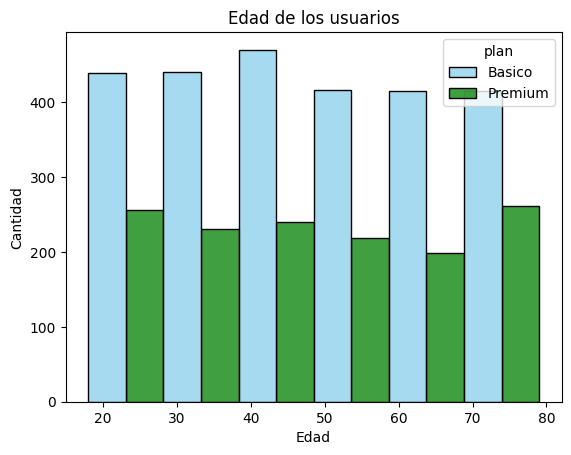

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, bins=6, x='age', hue='plan', multiple='dodge', palette=['skyblue','green'])
plt.title('Edad de los usuarios')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.show()

💡Insights:
- Los datos de la edad cuentan con una distribución uniforme, sin presentar una tendencia clara o mayor en algun grupo de edad.
- Existe una mayor demanda en todos los grupos de edad, hacia los planes básicos.

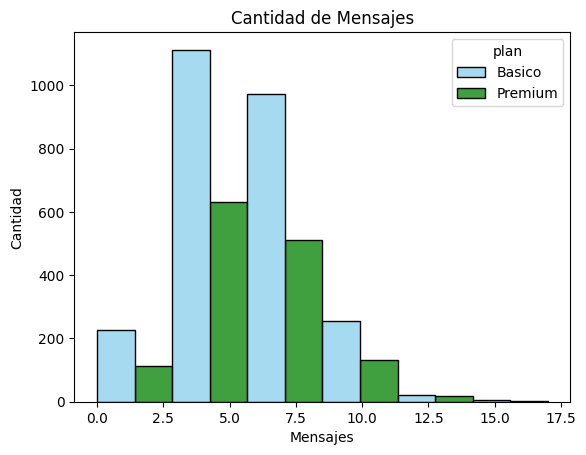

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, bins=6, x='cant_mensajes', hue='plan', multiple='dodge', palette=['skyblue','green'])
plt.title('Cantidad de Mensajes')
plt.xlabel('Mensajes')
plt.ylabel('Cantidad')
plt.show()

💡Insights:
- Hay un predominio en el uso de la mensajeria en el plan básico.
- La distribución esta sesgada hacia la derecha, siguiendo la misma tendencia en ambos planes.
- Haciendo una comparativa entre mensajes y llamada, no existe una tendencia predominante hacia la preferencia especifica de uno.

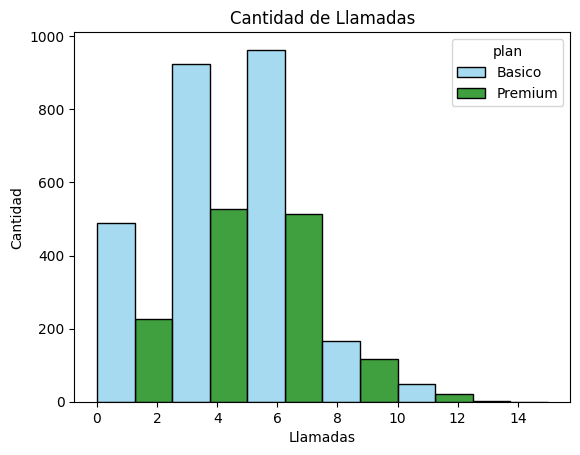

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, bins=6, x='cant_llamadas', hue='plan', multiple='dodge', palette=['skyblue','green'])
plt.title('Cantidad de Llamadas')
plt.xlabel('Llamadas')
plt.ylabel('Cantidad')
plt.show()

💡Insights:
- Hay un predominio en el uso de las llamadas en el plan básico.
- La distribución esta sesgada hacia la derecha, siguiendo la misma tendencia en ambos planes.
- Haciendo una comparativa entre llamada y mensajes, no existe una tendencia predominante hacia la preferencia especifica de uno.

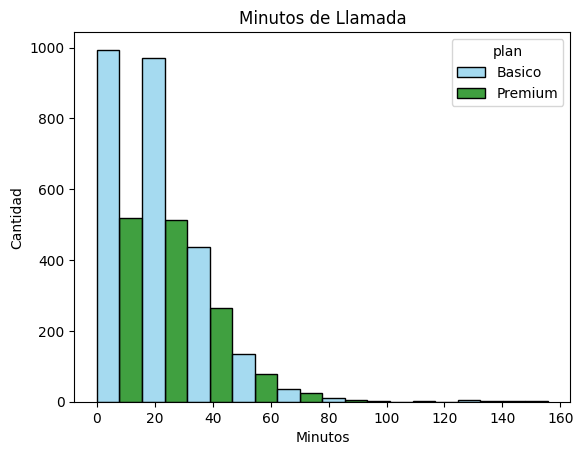

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, bins=10, x='cant_minutos_llamada', hue='plan', multiple='dodge', palette=['skyblue','green'])
plt.title('Minutos de Llamada')
plt.xlabel('Minutos')
plt.ylabel('Cantidad')
plt.show()

💡Insights:
- Hay un predominio en el uso de los minutos por llamada en el plan básico.
- La distribución esta sesgada hacia la derecha, siguiendo la misma tendencia en ambos planes. Lo que e traduce como un predominio de llamadas de poca duración.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

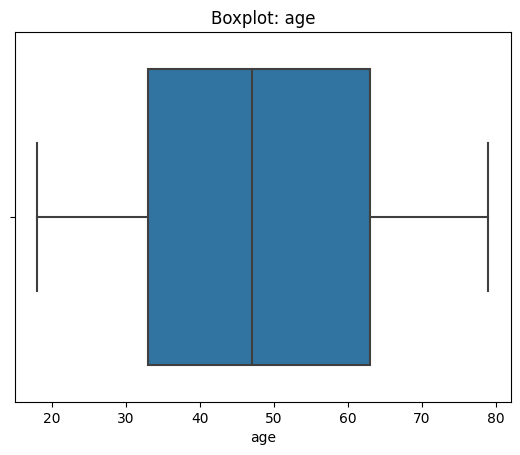

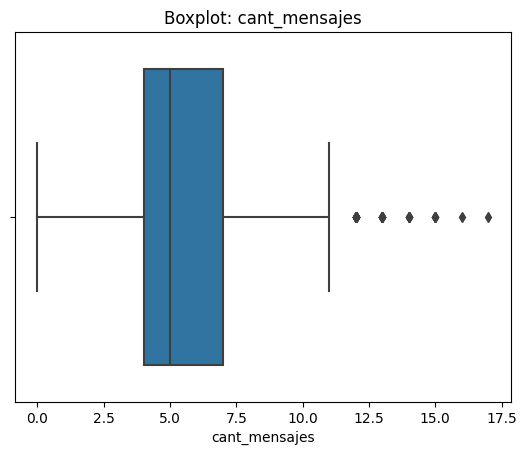

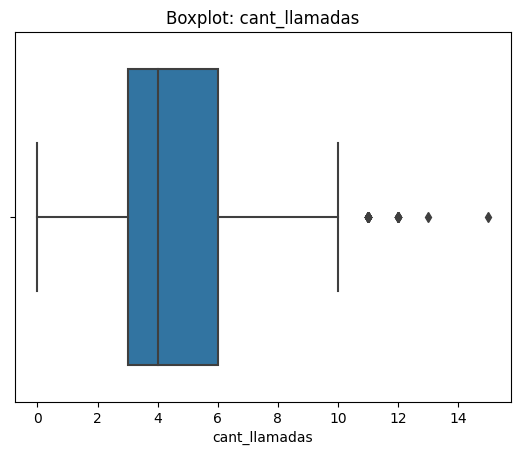

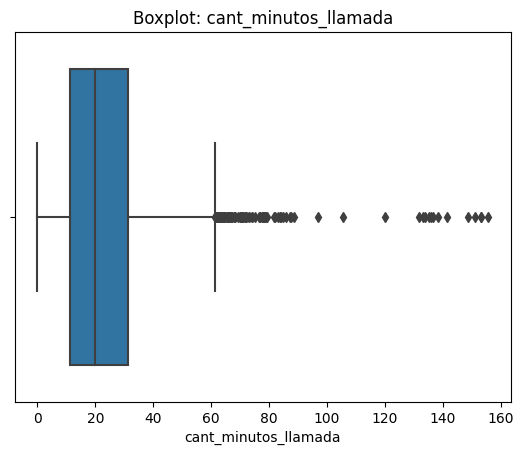

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: No presenta outliers, los valores se mantienen dentro de los limites del grafico.
- cant_mensajes: Si presenta outliers.
- cant_llamadas: Si presenta outliers.
- cant_minutos_llamada: Si presenta outliers.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f'Límites {col}:')
    print("Primer cuartil:", Q1)
    print("Tercer cuartil:", Q3)
    print("IQR:", IQR)
    print("Límite superior:", limite_superior)
    print()

Límites cant_mensajes:
Primer cuartil: 4.0
Tercer cuartil: 7.0
IQR: 3.0
Límite superior: 11.5

Límites cant_llamadas:
Primer cuartil: 3.0
Tercer cuartil: 6.0
IQR: 3.0
Límite superior: 10.5

Límites cant_minutos_llamada:
Primer cuartil: 11.094999999999999
Tercer cuartil: 31.185
IQR: 20.09
Límite superior: 61.31999999999999



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,22.836934
std,2.358416,2.144238,16.590213
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.095000
50%,5.000000,4.000000,19.740000
75%,7.000000,6.000000,31.185000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? Se mantienen los outliers por tratarse de una actividad que puede tener picos muy significativos en relación con el uso del servicio de telefonia, estos valores nos brindan información sobre conductas o tendencias que tambien nos permiten tomar decisiones relevantes para los objetivos del negocio.
- cant_llamadas: mantener o no outliers, porqué? Se mantienen los outliers por tratarse de una actividad que puede tener picos muy significativos en relación con el uso del servicio de telefonia, estos valores nos brindan información sobre conductas o tendencias que tambien nos permiten tomar decisiones relevantes para los objetivos del negocio.
- cant_minutos_llamada: mantener o no outliers, porqué? Se mantienen los outliers por tratarse de una actividad que puede tener picos muy significativos en relación con el uso del servicio de telefonia, estos valores nos brindan información sobre conductas o tendencias que tambien nos permiten tomar decisiones relevantes para los objetivos del negocio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def clasificar_clientes(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    if pd.isna(llamadas) or pd.isna(mensajes):
        return "Error de datos"

    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_clientes, axis=1)
print(user_profile['grupo_uso'].value_counts())

Uso medio         2943
Bajo uso           778
Alto uso           278
Error de datos       1
Name: grupo_uso, dtype: int64


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edades(row):
    edad = row['age']

    if pd.isna(edad):
        return "Error de datos"

    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edades, axis=1)
print(user_profile['grupo_edad'].value_counts())

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

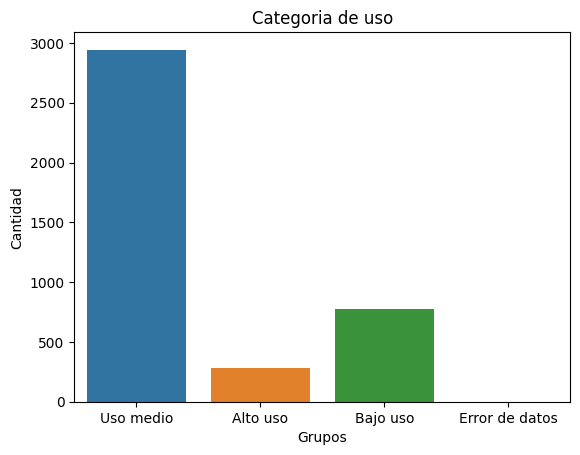

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Categoria de uso')
plt.xlabel('Grupos')
plt.ylabel('Cantidad')
plt.show()

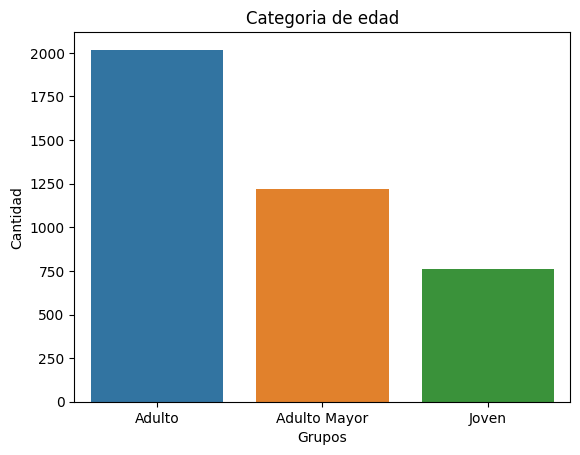

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Categoria de edad')
plt.xlabel('Grupos')
plt.ylabel('Cantidad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En la base de usuarios, en la columna de edad se encontraron valores sentinela (-999), los cuales fueron reemplazados por la mediana.
- En la columna de city, de la misma base de usuarios, se encontraron valores faltantes "?" los cuales pueron reemplazados por NA.
- En la columna de fecha de registro, se encontraron valores del año 2026, valor imposible ya que la base de datos es del año 2024 y posteriores. En este caso, estos valores fueron cambiados a NA.
- En la columna churn_date de la misma base de datos, dato que corresponde a la fecha de cancelación del servicio, tenemos datos NA que corresponden a aquellos clientes que se encuentran activos, por lo que no fue necesario llevar a cabo ninguna acción.
- Para el caso del DF usage, encontramos la columna de fecha, en la cual encontramos valores nan en un 1.25% lo cual no representa alguna afectación a nuestros calculos, por lo que se decidió ignorarlo.
- En el mismo DF de usage, encontramos las columnas 'duration' y 'length', las cuales registran el tiempo de la llamada y longitud de mensajes respectivamente, y ambas dependen directamente de la columna 'type', la cual registra la variable de llamada o mensaje, y esto alimenta la columna que correponde de duracion o longitud. Haciendo un anslisis en estas columnas, encontramos doble captura en menos del 1% de los datos, para esta situación aplicamos NA a los valores erroneos para evitar que afectaran nuestros análisis.      


🔍 **Segmentos por Edad**
- En el registro de edad encontramos un distribución uniforme, con una mayor concentracion en el segmento adulto que comprendo de los 30 a 60 años.
- En el segmento que se tiene menor registro de usuarios, es el segmento joven menor a 30 años.


📊 **Segmentos por Nivel de Uso**
- Existe una tendencia similar, con sesgo hacia la derecha en los registros de llamada y mensajes.
- Encontramos outliers en los registros de mensajes, llamadas y el tiempo de llamada, pero son considerados como registros correctos de usuarios con alta demanda de servicio.


➡️ Esto sugiere que encontramos registros suficientes para poder llevar análisis y propuestas para la toma de decisiones encaminadas a la mejora de la prestación del servicio y el incremento de la rentabilidad del negocio.


💡 **Recomendaciones**
- Enfocar estrategias de mercadotecnia para atraer mas al sector joven, esto con el objetivo a establecer relaciones comerciales a largo plazo.
- Análisis a detalle de los casos de alto consumo, para aplicar estrategias en donde se ofrezcan promociones para incrementar del servicio básico a premium.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`